In [1]:
import os, sys
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")                      # run everything from the project root
sys.path.insert(0, os.getcwd())

import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
%matplotlib inline
pd.set_option("display.max_columns", 50)

# 01 · Exploratory Data Analysis
UCI **Online Shoppers Purchasing Intention** dataset: one row per browsing session.

In [2]:
from src.data_preprocessing import load_raw
from src import evaluation

df = load_raw()
print(df.shape)
df.head()

(12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.315166,3.321784,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12330.0,80.818611,176.779107,0.0,0.000000,7.500000,93.256250,3398.750000
Informational,12330.0,0.503569,1.270156,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12330.0,34.472398,140.749294,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12330.0,31.731468,44.475503,0.0,7.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12330.0,1194.746220,1913.669288,0.0,184.137500,598.936905,1464.157214,63973.522230
BounceRates,12330.0,0.022191,0.048488,0.0,0.000000,0.003112,0.016813,0.200000
ExitRates,12330.0,0.043073,0.048597,0.0,0.014286,0.025156,0.050000,0.200000
PageValues,12330.0,5.889258,18.568437,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12330.0,0.061427,0.198917,0.0,0.000000,0.000000,0.000000,1.000000


### Data quality checks

In [5]:
print('Missing values :', df.isna().sum().sum())
print('Duplicate rows :', df.duplicated().sum())
print('Months         :', sorted(df.Month.unique()))

Missing values : 0
Duplicate rows : 125
Months         : ['Aug', 'Dec', 'Feb', 'Jul', 'June', 'Mar', 'May', 'Nov', 'Oct', 'Sep']


### Target (not used for clustering – only to profile segments later)

In [6]:
print(df.Revenue.value_counts(normalize=True).round(3))
df.VisitorType.value_counts()

Revenue
False    0.845
True     0.155
Name: proportion, dtype: float64


VisitorType
Returning_Visitor    10551
New_Visitor           1694
Other                   85
Name: count, dtype: int64

### Distributions
Counts, durations and page values are extremely right-skewed with many zeros → we will log-transform them.

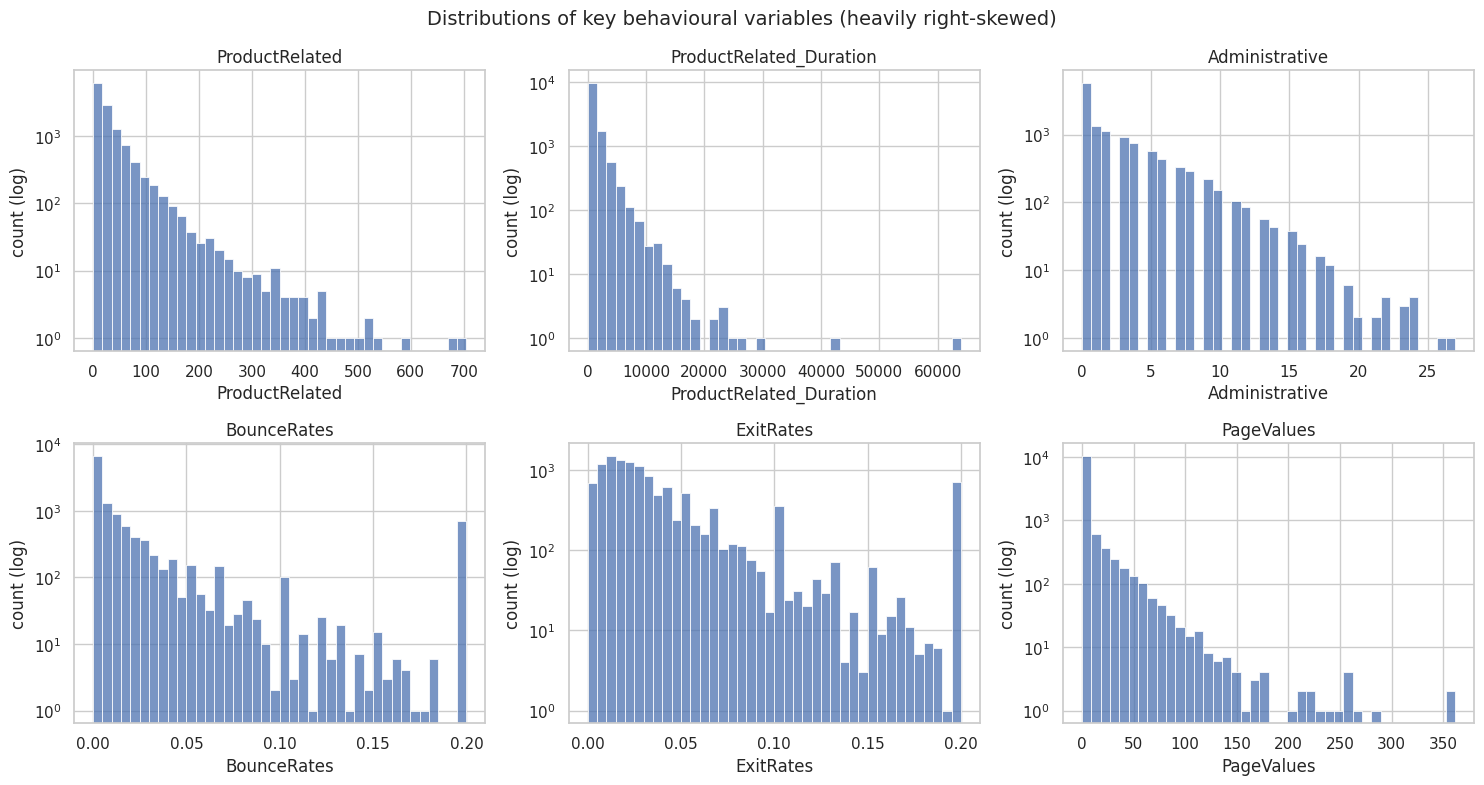

In [7]:
fig = evaluation.plot_distributions(df); plt.show()

### Correlations

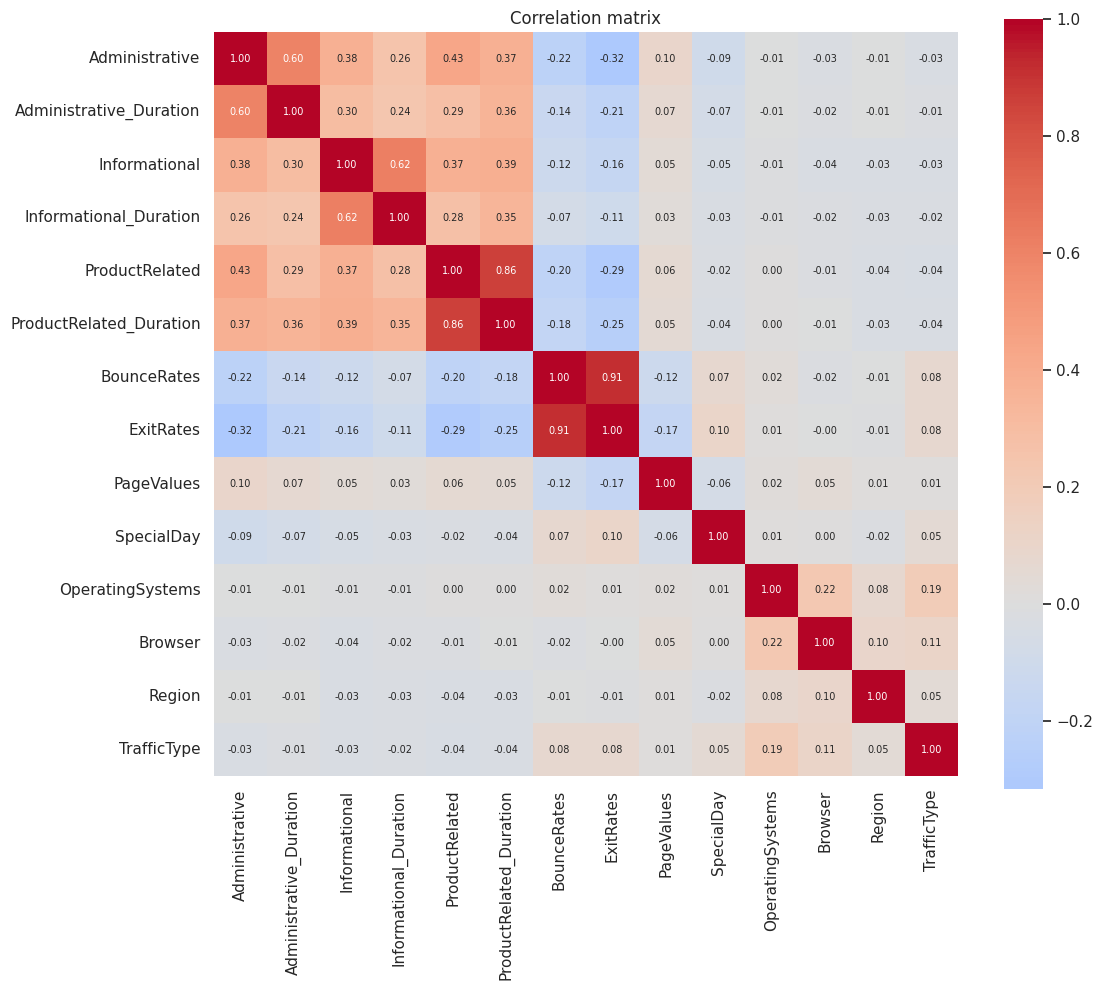

In [8]:
fig = evaluation.plot_correlation(df); plt.show()

`BounceRates` and `ExitRates` are almost collinear, and page counts correlate strongly with their durations.

### Purchase rate by visitor type and month

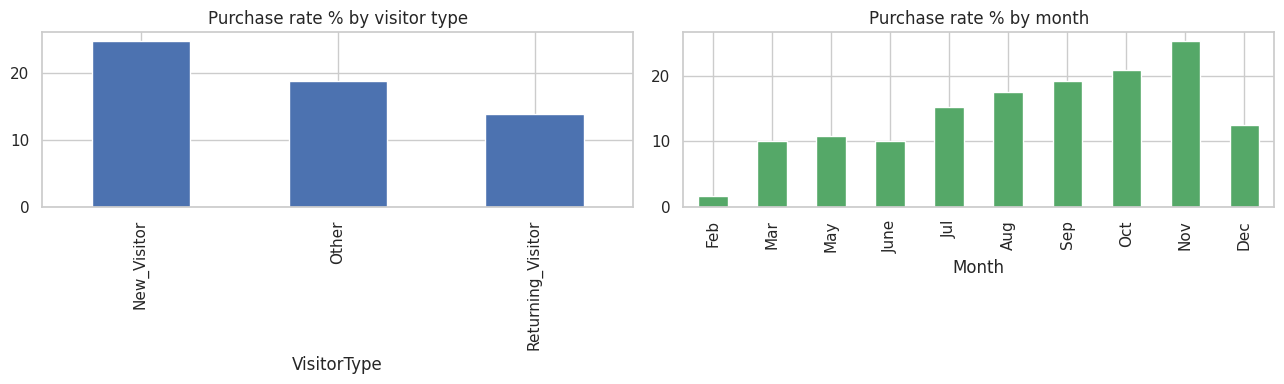

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
(df.groupby('VisitorType').Revenue.mean()*100).plot.bar(ax=ax[0], color='#4C72B0', title='Purchase rate % by visitor type')
order = ['Feb','Mar','May','June','Jul','Aug','Sep','Oct','Nov','Dec']
(df.groupby('Month').Revenue.mean().reindex(order)*100).plot.bar(ax=ax[1], color='#55A868', title='Purchase rate % by month')
plt.tight_layout(); plt.show()

### Key takeaways
- 12,330 sessions, **no missing values**, but **125 duplicate rows**.
- Only ~15% of sessions end in a purchase (imbalanced).
- `June` is spelled differently from the other 3-letter months.
- Heavy skew → log transforms and scaling are required before K-Means.
- New visitors convert more than returning ones; November is the peak month.